# Phase 3

In [16]:
import os
import time
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.regression import RandomForestRegressor, DecisionTreeRegressor, LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# --- DYNAMIC PATH CONFIGURATION ---
if "notebooks" in os.getcwd():
    BASE_DIR = os.path.dirname(os.getcwd())
else:
    BASE_DIR = os.getcwd()

OUTPUT_PARQUET = "file://" + os.path.join(BASE_DIR, "data", "processed", "operational_data.parquet")
OUTPUT_DIR = "file://" + os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

spark = SparkSession.builder \
    .appName("TransitMLPipeline") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .master("local[*]") \
    .getOrCreate()

# Load data
df_ml = spark.read.parquet(OUTPUT_PARQUET)

# Feature Engineering
categorical_cols = [c for c in ["LineName", "ServiceCode", "day_of_week"] if c in df_ml.columns]
numeric_cols = ["hour_of_day", "Sequence", "fare_price"]

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in categorical_cols]
encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_vec") for c in categorical_cols]
assembler_inputs = [f"{c}_vec" for c in categorical_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

pipeline = Pipeline(stages=indexers + encoders + [assembler])
pipeline_model = pipeline.fit(df_ml)
df_ml_ready = pipeline_model.transform(df_ml).select("features", "delay_minutes")

# Train/Test Split
train_data, test_data = df_ml_ready.randomSplit([0.8, 0.2], seed=42)

# REQUIREMENT: Cache train/test data to optimize ML training
train_data.cache()
test_data.cache()

# Define Models
lr = LinearRegression(featuresCol="features", labelCol="delay_minutes", predictionCol="prediction_lr")
dt = DecisionTreeRegressor(featuresCol="features", labelCol="delay_minutes", predictionCol="prediction_dt")
rf = RandomForestRegressor(featuresCol="features", labelCol="delay_minutes", predictionCol="prediction_rf", numTrees=10)

# Train Models & Track Algorithmic/Model Efficiency (Time)
print("\nTraining Linear Regression...")
t0 = time.time()
model_lr = lr.fit(train_data)
lr_time = time.time() - t0
print(f"Done. Time: {lr_time:.2f}s")

print("Training Decision Tree...")
t0 = time.time()
model_dt = dt.fit(train_data)
dt_time = time.time() - t0
print(f"Done. Time: {dt_time:.2f}s")

print("Training Random Forest with CrossValidator...")
t0 = time.time()
# REQUIREMENT: CrossValidator implementation
paramGrid = ParamGridBuilder().addGrid(rf.numTrees, [5, 10]).build()
cv = CrossValidator(estimator=rf, estimatorParamMaps=paramGrid, \
                    evaluator=RegressionEvaluator(labelCol="delay_minutes", predictionCol="prediction_rf", metricName="rmse"), \
                    numFolds=2)
model_rf = cv.fit(train_data)
rf_time = time.time() - t0
print(f"Done. Time: {rf_time:.2f}s")


Training Linear Regression...


26/08/03 01:29:09 WARN Instrumentation: [e8ac0f4e] regParam is zero, which might cause numerical instability and overfitting.
26/08/03 01:29:12 WARN Instrumentation: [e8ac0f4e] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


Done. Time: 3.38s
Training Decision Tree...


Done. Time: 3.12s
Training Random Forest with CrossValidator...


Done. Time: 18.76s


In [17]:
# Evaluation
pred_lr = model_lr.transform(test_data)
pred_dt = model_dt.transform(test_data)
pred_rf = model_rf.transform(test_data)

evaluator_rmse = RegressionEvaluator(labelCol="delay_minutes", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="delay_minutes", predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol="delay_minutes", predictionCol="prediction", metricName="r2")

def evaluate_model(predictions, pred_col, model_name, train_time):
    preds = predictions.withColumnRenamed(pred_col, "prediction")
    rmse = evaluator_rmse.evaluate(preds)
    mae  = evaluator_mae.evaluate(preds)
    r2   = evaluator_r2.evaluate(preds)
    print(f"--- {model_name} ---")
    print(f"RMSE: {rmse:.4f} minutes")
    print(f"MAE:  {mae:.4f} minutes")
    print(f"R2:   {r2:.4f}")
    print(f"Model Efficiency (RMSE/sec): {rmse/train_time:.4f}\n")
    return {"Model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2, "Time(s)": train_time}

metrics_lr = evaluate_model(pred_lr, "prediction_lr", "Linear Regression", lr_time)
metrics_dt = evaluate_model(pred_dt, "prediction_dt", "Decision Tree", dt_time)
metrics_rf = evaluate_model(pred_rf, "prediction_rf", "Random Forest (CV)", rf_time) # CV outputs 'prediction' by default

--- Linear Regression ---
RMSE: 3.9773 minutes
MAE:  3.1205 minutes
R2:   0.0200
Model Efficiency (RMSE/sec): 1.1775

--- Decision Tree ---
RMSE: 2.7237 minutes
MAE:  1.8421 minutes
R2:   0.5404
Model Efficiency (RMSE/sec): 0.8731

--- Random Forest (CV) ---
RMSE: 3.2937 minutes
MAE:  2.3498 minutes
R2:   0.3279
Model Efficiency (RMSE/sec): 0.1756



# Phase 4

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# Extract predictions (Random Forest) to Pandas
pdf_predictions = pred_rf.select("delay_minutes", "prediction_rf").toPandas()
pdf_predictions.rename(columns={"prediction_rf": "predicted_delay"}, inplace=True)

# Extract hourly delay data
# --- FIX: Register df_ml as a temporary view so Spark SQL can find it ---
df_ml.createOrReplaceTempView("bus_operations")

df_delay_by_hour = spark.sql("""
    SELECT hour_of_day, ROUND(AVG(delay_minutes), 2) as avg_delay_mins
    FROM bus_operations GROUP BY hour_of_day ORDER BY hour_of_day ASC
""")
pdf_hourly = df_delay_by_hour.toPandas()

# Create model metrics dataframe for plotting
model_metrics = pd.DataFrame([metrics_lr, metrics_dt, metrics_rf])

### Visualization 1: Model Performance Comparison

/tmp/ipykernel_150288/208413675.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="RMSE", data=model_metrics, ax=axes[0], palette="Blues_r")
/tmp/ipykernel_150288/208413675.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="R2", data=model_metrics, ax=axes[1], palette="Greens_r")


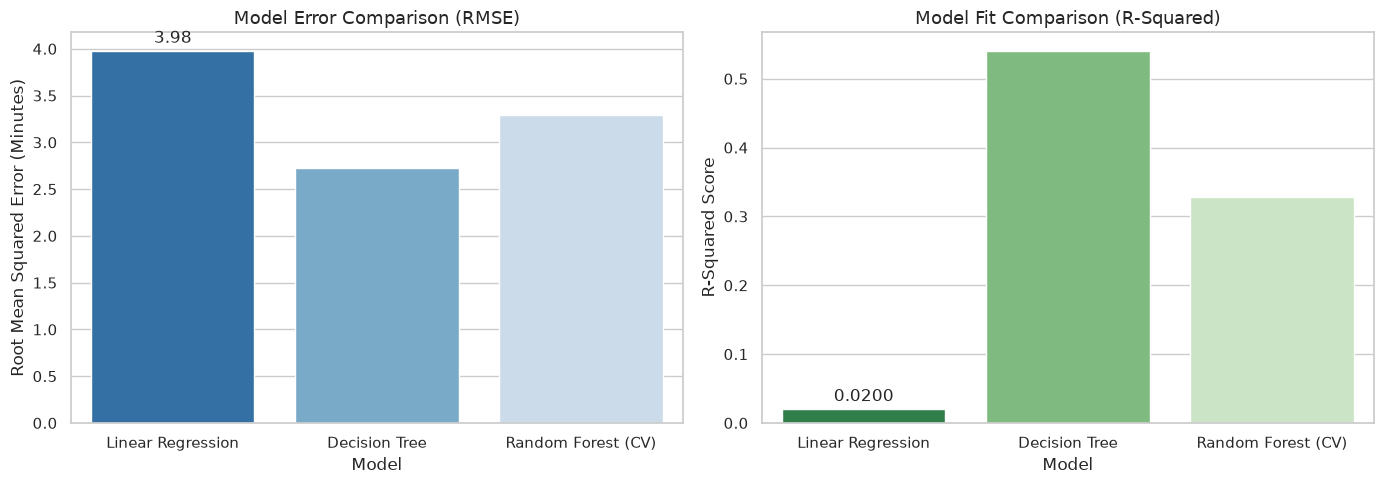

Saved plot to file:///media/zenusha/Extra/Notes/Big_Data/official/outputs/model_comparison.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x="Model", y="RMSE", data=model_metrics, ax=axes[0], palette="Blues_r")
axes[0].set_title("Model Error Comparison (RMSE)", fontsize=13)
axes[0].set_ylabel("Root Mean Squared Error (Minutes)")
axes[0].bar_label(axes[0].containers[0], fmt='%.2f', padding=3)

sns.barplot(x="Model", y="R2", data=model_metrics, ax=axes[1], palette="Greens_r")
axes[1].set_title("Model Fit Comparison (R-Squared)", fontsize=13)
axes[1].set_ylabel("R-Squared Score")
axes[1].bar_label(axes[1].containers[0], fmt='%.4f', padding=3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison.png", dpi=300)
plt.show()
print(f"Saved plot to {OUTPUT_DIR}/model_comparison.png")

### Visualization 2: Actual vs Predicted Scatter

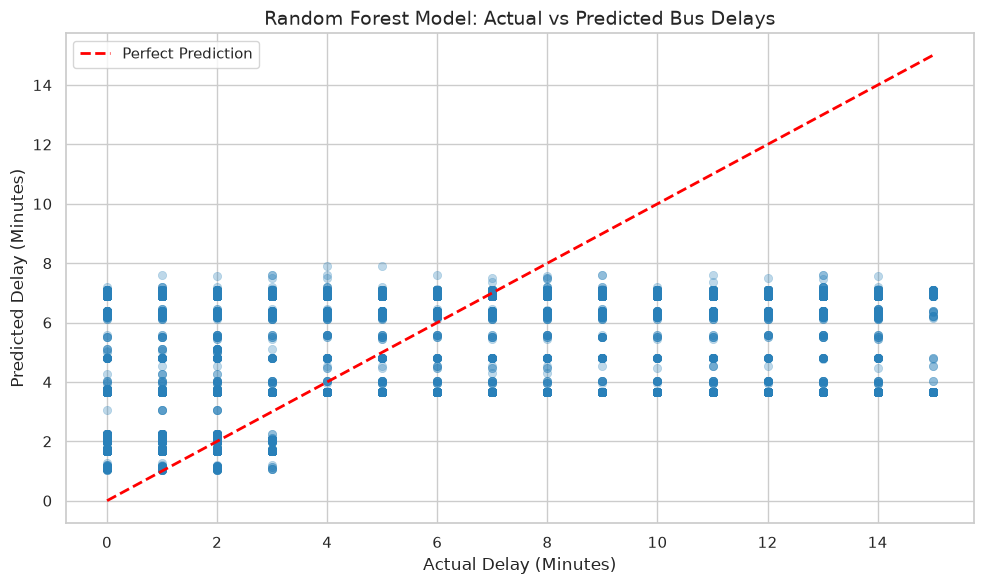

Saved plot to file:///media/zenusha/Extra/Notes/Big_Data/official/outputs/actual_vs_predicted.png


In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="delay_minutes", y="predicted_delay", data=pdf_predictions, alpha=0.3, color="#2980b9", edgecolor=None)
max_val = max(pdf_predictions["delay_minutes"].max(), pdf_predictions["predicted_delay"].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction')
plt.title("Random Forest Model: Actual vs Predicted Bus Delays", fontsize=14)
plt.xlabel("Actual Delay (Minutes)", fontsize=12)
plt.ylabel("Predicted Delay (Minutes)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/actual_vs_predicted.png", dpi=300)
plt.show()
print(f"Saved plot to {OUTPUT_DIR}/actual_vs_predicted.png")

### Visualization 3: Average Delay by Hour

/tmp/ipykernel_150288/2050186890.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="hour_of_day", y="avg_delay_mins", data=pdf_hourly, palette="Reds_r")


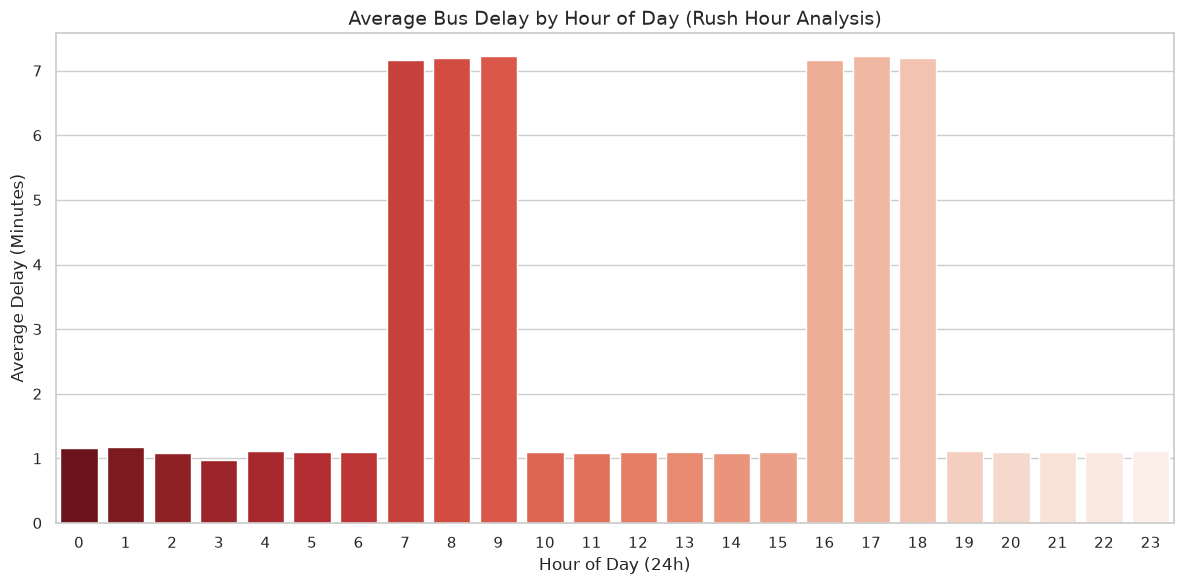

Saved plot to file:///media/zenusha/Extra/Notes/Big_Data/official/outputs/hourly_delay_trend.png


In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(x="hour_of_day", y="avg_delay_mins", data=pdf_hourly, palette="Reds_r")
plt.title("Average Bus Delay by Hour of Day (Rush Hour Analysis)", fontsize=14)
plt.xlabel("Hour of Day (24h)", fontsize=12)
plt.ylabel("Average Delay (Minutes)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hourly_delay_trend.png", dpi=300)
plt.show()
print(f"Saved plot to {OUTPUT_DIR}/hourly_delay_trend.png")

### Visualization 4: Delay Distribution KDE

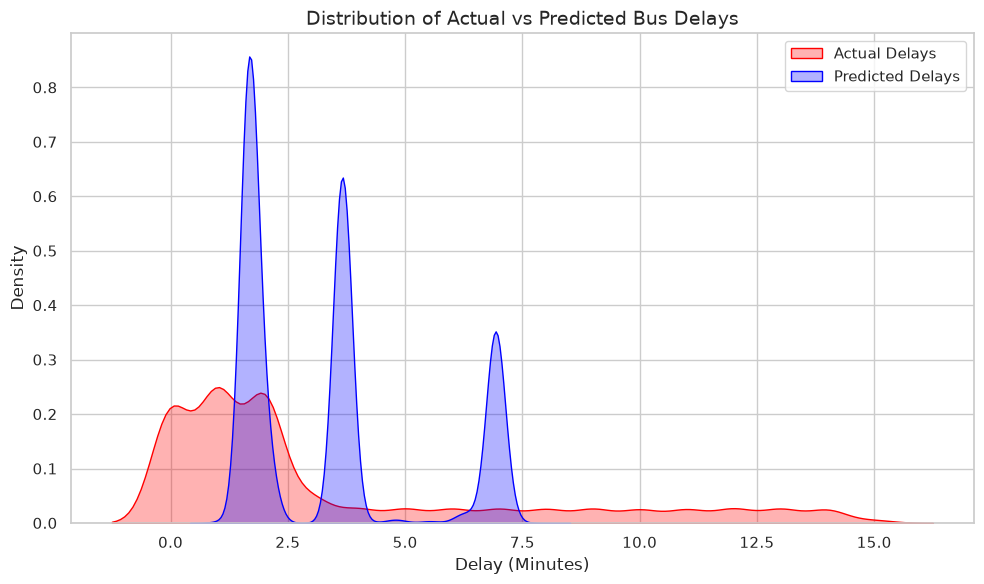

Saved plot to file:///media/zenusha/Extra/Notes/Big_Data/official/outputs/delay_distribution.png


In [22]:
plt.figure(figsize=(10, 6))
sns.kdeplot(pdf_predictions["delay_minutes"], color="red", label="Actual Delays", fill=True, alpha=0.3)
sns.kdeplot(pdf_predictions["predicted_delay"], color="blue", label="Predicted Delays", fill=True, alpha=0.3)
plt.title("Distribution of Actual vs Predicted Bus Delays", fontsize=14)
plt.xlabel("Delay (Minutes)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/delay_distribution.png", dpi=300)
plt.show()
print(f"Saved plot to {OUTPUT_DIR}/delay_distribution.png")